<a href="https://colab.research.google.com/github/Kirieshka124/ml_basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_K_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №4. Метод K-ближайших соседей

# Базовый алгоритм KNN

## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=20)

#### 1.2. Обучите модель KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=4)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

#### 1.3. Проверьте качество работы модели

In [ ]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
display(accuracy_score(y_test, pred_test))
display(y_test, pred_test)

0.95

array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0])

array([1, 2, 0, 1, 0, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0])

#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [ ]:
scores = []
max_neighbors = 15

for k in range(1, max_neighbors+1):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    score = accuracy_score(y_test, model.predict(X_test))
    scores.append(score)

results = pd.DataFrame({'k': [i for i in range(1, max_neighbors+1)], 'Accuracy': scores})
results

,k,Accuracy
0,1,0.95
1,2,0.95
2,3,0.95
3,4,0.95
4,5,0.95
5,6,0.95
6,7,0.95
7,8,0.95
8,9,0.95
9,10,1.00


### 2. KNN рукописный

#### 2.1. Возьмите два случайных тестовых объектов

In [ ]:
obj0_idx = 0
obj1_idx = 5
x1 = X_test.iloc[obj0_idx]
x2 = X_test.iloc[obj1_idx]
x2

,60
sepal length (cm),5.0
sepal width (cm),2.0
petal length (cm),3.5
petal width (cm),1.0


#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [ ]:
test_objects = [x1, x2]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
for i in range(len(test_objects)):
    sample = test_objects[i].values
    distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2) # axis=1 для расчета по строкам
    distances_df[f'Test object {i} dst'] = distance
distances_df

,Label,Test object 0 dst,Test object 1 dst
0,2,2.004994,3.518522
1,2,1.584298,2.906888
2,2,0.818535,2.100000
3,0,3.304542,2.280351
4,1,0.854400,1.596872
...,...,...,...
125,2,1.118034,1.997498
126,1,1.220656,1.126943
127,0,3.740321,3.257299
128,2,2.104757,3.629049


#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [ ]:
k=10
display(distances_df.sort_values('Test object 0 dst').head(k))
display(distances_df.sort_values('Test object 1 dst').head(k))

,Label,Test object 0 dst,Test object 1 dst
30,1,0.264575,1.652271
111,1,0.591608,1.135782
115,1,0.608276,2.085665
11,1,0.616441,1.726268
82,1,0.616441,1.870829
121,1,0.624500,1.824829
76,1,0.670820,1.479865
10,1,0.700000,2.161018
98,2,0.707107,1.881489
33,1,0.707107,1.749286


,Label,Test object 0 dst,Test object 1 dst
89,1,1.729162,0.360555
93,1,1.808314,0.458258
32,1,1.109054,0.670820
77,1,1.024695,0.714143
43,1,1.865476,0.721110
106,1,0.905539,0.883176
97,1,0.916515,0.916515
22,1,1.276715,0.921954
57,1,1.161895,0.921954
126,1,1.220656,1.126943


#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [ ]:
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
obj1 = distances_df.sort_values('Test object 1 dst').head(k)
print(f"Предсказание для первого объекта: {obj0['Label'].value_counts().index[0]}")
print(f"Предсказание для второго объекта: {obj1['Label'].value_counts().index[0]}")

Предсказание для первого объекта: 1
Предсказание для второго объекта: 1


#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [ ]:
print(f"Настоящее целевое значение для первого объекта: {y_test[obj0_idx]}")
print(f"Настоящее целевое значение для второго объекта: {y_test[obj1_idx]}")

Настоящее целевое значение для первого объекта: 1
Настоящее целевое значение для второго объекта: 1


## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### KNN из sklearn

#### 3.1. Разбейте данные на обучение и тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=10)

Затем нормализуйте данные:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=20)
model.fit(X_train, y_train)
pred_test = model.predict(X_test)

#### 3.3. Проверьте качество работы модели

In [ ]:
from sklearn.metrics import r2_score

r2_score(y_test, pred_test)

0.659463124739666

#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

,k,R2 score
0,1,0.700158
1,2,0.303141
2,3,0.063961
3,4,0.170933
4,5,0.433847
5,6,0.572078
6,7,0.607178
7,8,0.607974
8,9,0.545058
9,10,0.572395


<Axes: xlabel='k'>

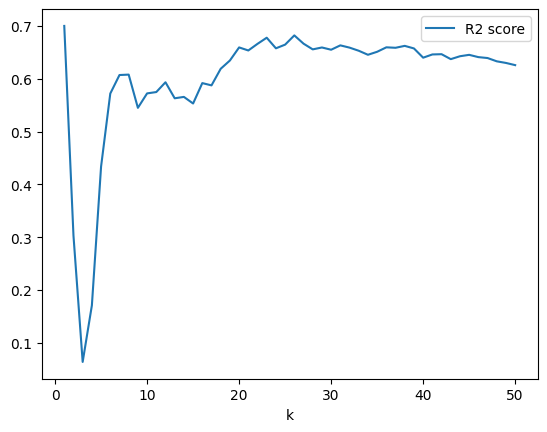

In [ ]:
scores = []
k_range = 50

for k in range(1, k_range+1):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    score = r2_score(y_test, model.predict(X_test))
    scores.append(score)

results = pd.DataFrame({'k': [i for i in range(1, k_range+1)], 'R2 score': scores})
display(results)
results.plot(x='k', y='R2 score')

### 4. KNN рукописный

#### 4.1. Возьмите два случайных тестовых объектов

In [ ]:
obj0_idx = 0
obj1_idx = 5
x1 = X_test.iloc[obj0_idx]
x2 = X_test.iloc[obj1_idx]
x2

,1982
MedInc,3.056500
HouseAge,14.000000
AveRooms,5.696065
AveBedrms,1.070556
Population,3952.000000
AveOccup,2.681140
Latitude,38.670000
Longitude,-120.810000


#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [ ]:
test_objects = [x1, x2]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
for i in range(len(test_objects)):
    sample = test_objects[i].values
    distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
    distances_df[f'Test object {i} dst'] = distance
distances_df

,Label,Test object 0 dst,Test object 1 dst
0,1.37800,58.304122,3500.146455
1,5.00001,863.088928,2684.025000
2,1.57900,1119.487886,2428.204812
3,1.09400,1289.021601,2258.002092
4,0.88900,1131.012011,2416.002085
...,...,...,...
20625,3.10300,244.346518,3304.080896
20626,2.55000,1508.019472,2039.014250
20627,2.41900,1755.015129,1792.020823
20628,1.50000,1755.154551,1792.134437


#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [ ]:
k=3
display(distances_df.sort_values('Test object 0 dst').head(k))
display(distances_df.sort_values('Test object 1 dst').head(k))

,Label,Test object 0 dst,Test object 1 dst
9512,1.580,4.418196,3545.002499
4228,3.229,4.437614,3547.001523
9459,1.219,5.647924,3546.000586


,Label,Test object 0 dst,Test object 1 dst
15912,1.569,3549.004199,6.868470
16799,1.772,3545.005558,7.138834
2365,1.063,3555.004075,8.302851


#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [ ]:
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
obj1 = distances_df.sort_values('Test object 1 dst').head(k)
print(f"Предсказание для первого объекта: {obj0['Label'].median()}")
# т.к. задача регрессии, берем медиану (лучше среднего значения, тк у нас возможны выбросы) от ближайших соседей
print(f"Предсказание для второго объекта: {obj1['Label'].median()}")

Предсказание для первого объекта: 1.58
Предсказание для второго объекта: 1.569


#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [ ]:
print(f"Настоящее целевое значение для первого объекта: {y_test[obj0_idx]}")
print(f"Настоящее целевое значение для второго объекта: {y_test[obj1_idx]}")

Настоящее целевое значение для первого объекта: 1.674
Настоящее целевое значение для второго объекта: 1.188


Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# Weighted KNN

## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [ ]:
df = X[['sepal length (cm)', 'petal width (cm)']]
df

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2
...,...,...
145,6.7,2.3
146,6.3,1.9
147,6.5,2.0
148,6.2,2.3


### Визуализируйте ваши данные на графике

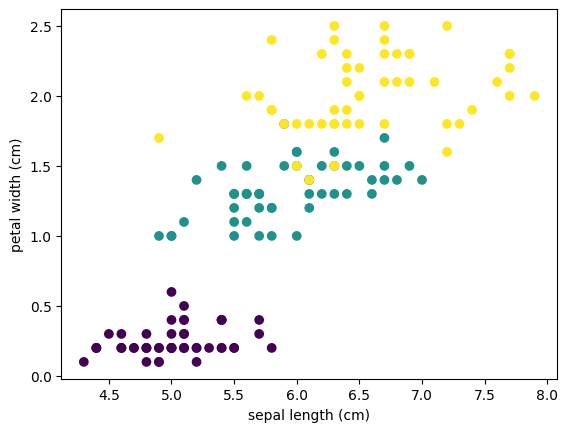

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['sepal length (cm)'], df['petal width (cm)'], c=y) # c=y задает цвет по классам
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')
plt.show()

### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, y, random_state=10, test_size=10)

#### 1.2. Обучите модель KNN на 50 соседях

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=50)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

In [ ]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
display(accuracy_score(y_test, pred_test))
display(y_test, pred_test)

0.9

array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1])

array([1, 2, 0, 1, 0, 0, 1, 1, 0, 1])

#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
import numpy as np

obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df['Test object 0 dst'] = distance
distances_df

,Label,Test object 0 dst
0,1,0.728011
1,2,0.781025
2,1,0.800000
3,0,1.780449
4,0,1.562050
...,...,...
135,2,0.921954
136,1,0.700000
137,0,1.081665
138,2,1.029563


#### 1.5. Выберите топ  k  соседей


In [ ]:
k=10
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
21,1,0.100000
92,1,0.100000
65,2,0.200000
86,1,0.200000
40,1,0.223607
91,2,0.223607
47,1,0.223607
44,1,0.223607
131,1,0.223607
125,1,0.282843


#### 1.6. Выведите финальное предсказание для этого объекта

In [ ]:
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
print(f"Предсказание для объекта: {obj0['Label'].value_counts().index[0]}")

Предсказание для объекта: 1


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
print(f"Настоящее целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Настоящее целевое значение для объекта: 1
Предсказанное целевое значение для объекта: 1


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

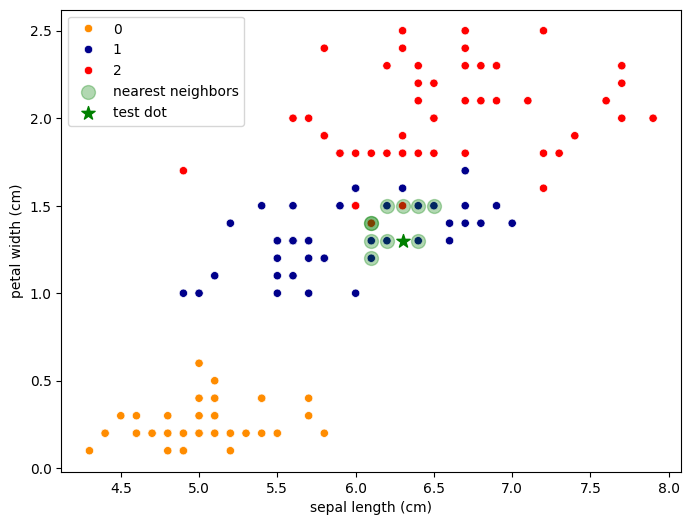

In [ ]:
import seaborn as sns

cmap_bold = ["darkorange", "darkblue", "red"]

nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train['sepal length (cm)'],
    y=X_train['petal width (cm)'],
    hue=y_train,
    palette=cmap_bold
)

plt.scatter(X_train.iloc[nearest_neigbors_idxs]['sepal length (cm)'], X_train.iloc[nearest_neigbors_idxs]['petal width (cm)'],
            c='g', alpha=0.3, marker='o', s=100, label='nearest neighbors')

plt.scatter(X_test.iloc[obj0_idx]['sepal length (cm)'], X_test.iloc[obj0_idx]['petal width (cm)'], c='g', marker='*', s=100, label='test dot')
plt.legend()

### 2. Weighted KNN

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [ ]:
model = KNeighborsClassifier(n_neighbors=50, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 2.2. Проверьте качество работы модели


In [ ]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
display(accuracy_score(y_test, pred_test))
display(y_test, pred_test)

0.9

array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1])

array([1, 2, 0, 1, 0, 1, 2, 1, 0, 1])

#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
import numpy as np

obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df[f'Test object 0 dst'] = distance
distances_df

,Label,Test object 0 dst
0,1,0.728011
1,2,0.781025
2,1,0.800000
3,0,1.780449
4,0,1.562050
...,...,...
135,2,0.921954
136,1,0.700000
137,0,1.081665
138,2,1.029563


#### 2.4. Выберите топ  k  соседей


In [ ]:
k=10
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
21,1,0.100000
92,1,0.100000
65,2,0.200000
86,1,0.200000
40,1,0.223607
91,2,0.223607
47,1,0.223607
44,1,0.223607
131,1,0.223607
125,1,0.282843


#### 2.5. Рассчитайте вес для каждого соседа

In [ ]:
distances_df['weight'] = 1 / distances_df['Test object 0 dst']
distances_df

,Label,Test object 0 dst,weight
0,1,0.728011,1.373606
1,2,0.781025,1.280369
2,1,0.800000,1.250000
3,0,1.780449,0.561656
4,0,1.562050,0.640184
...,...,...,...
135,2,0.921954,1.084652
136,1,0.700000,1.428571
137,0,1.081665,0.924500
138,2,1.029563,0.971286


#### 2.6. Выведите финальное предсказание для этого объекта

In [ ]:
display(f"Вес для класса 0 - {distances_df[distances_df['Label'] == 0]['weight'].sum()}",
        f"Вес для класса 1 - {distances_df[distances_df['Label'] == 1]['weight'].sum()}",
        f"Вес для класса 2 - {distances_df[distances_df['Label'] == 2]['weight'].sum()}")

'Вес для класса 0 - 28.712837854932715'

'Вес для класса 1 - 109.08778843949642'

'Вес для класса 2 - 63.725176242643386'

#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
print(f"Настоящее целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Настоящее целевое значение для объекта: 1
Предсказанное целевое значение для объекта: 1


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

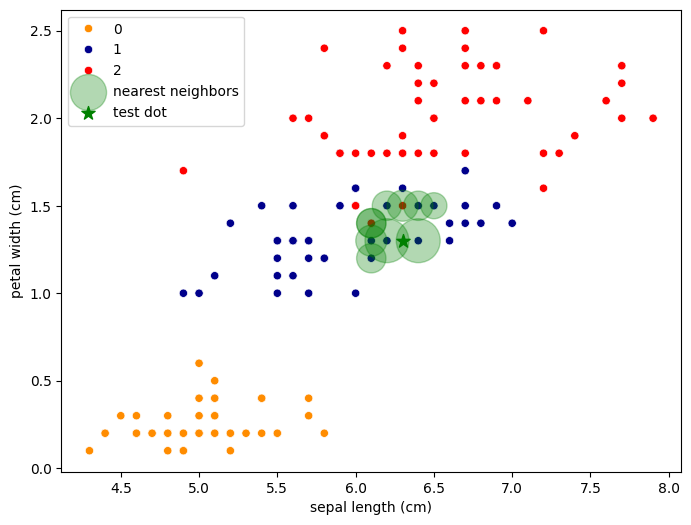

In [ ]:
import seaborn as sns

cmap_bold = ["darkorange", "darkblue", "red"]

nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train["sepal length (cm)"],
    y=X_train["petal width (cm)"],
    hue=y_train,
    palette=cmap_bold
)

plt.scatter(X_train['sepal length (cm)'].iloc[nearest_neigbors_idxs], X_train['petal width (cm)'].iloc[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=distances_df['weight'].iloc[nearest_neigbors_idxs]*100, label='nearest neighbors')

plt.scatter(X_test['sepal length (cm)'].iloc[obj0_idx], X_test['petal width (cm)'].iloc[obj0_idx], c='g', marker='*', s=100, label='test dot')
plt.legend()

### 3. Еще одна задача классификации

### Получение данных

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
import pandas as pd


data = fetch_olivetti_faces(shuffle=True, random_state=9)

X = pd.DataFrame(data['data'])
y = data['target']

X.head()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.723140,0.710744,0.714876,0.731405,0.735537,0.752066,0.772727,0.793388,0.814050,0.834711,...,0.793388,0.904959,0.549587,0.409091,0.491736,0.487603,0.471074,0.483471,0.475207,0.475207
1,0.289256,0.157025,0.148760,0.190083,0.169421,0.194215,0.404959,0.607438,0.669421,0.677686,...,0.438017,0.400826,0.421488,0.429752,0.433884,0.425620,0.438017,0.438017,0.210744,0.206612
2,0.586777,0.595041,0.681818,0.694215,0.714876,0.698347,0.714876,0.727273,0.743802,0.739669,...,0.495868,0.380165,0.400826,0.330579,0.148760,0.119835,0.123967,0.115702,0.119835,0.107438
3,0.235537,0.351240,0.479339,0.545455,0.566116,0.566116,0.595041,0.607438,0.619835,0.623967,...,0.169421,0.198347,0.202479,0.214876,0.202479,0.214876,0.214876,0.214876,0.210744,0.206612
4,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893


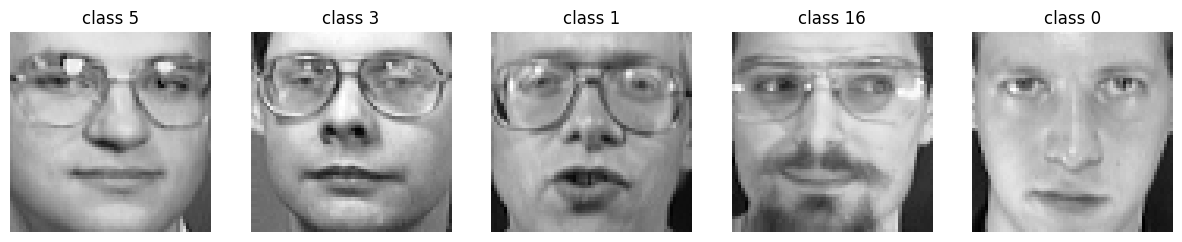

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(15, 8))

for i in range(0, 5):
    ax[i].imshow(X.iloc[i].values.reshape((64, 64)), cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'class {y[i]}')

plt.show()

In [ ]:
y

array([ 5,  3,  1, 16,  0,  1, 12,  9, 26, 37, 20,  5, 10, 27, 10, 34, 13,
       26, 17, 31,  9,  7, 31, 37, 31, 35, 18, 29, 29,  4, 21, 20, 23,  7,
        9, 18, 22,  2,  1, 39, 36,  8, 34, 32,  3, 20,  3,  9, 37, 32, 34,
       15,  9, 16, 36, 16, 13,  7, 29,  6, 13,  4, 16,  0,  8,  1, 25,  3,
       18, 29,  8, 35,  2, 25, 21, 31, 35, 23, 30, 28,  4, 10, 11, 27, 29,
       39,  5, 12, 29, 26, 15,  2, 39,  6, 30, 37, 25, 32, 35, 24, 15, 24,
        2, 19, 22,  0, 38,  5, 22, 28,  6, 38,  6,  3, 33, 12, 36,  8, 27,
       19, 25, 36, 10, 37,  9, 33, 10, 28, 32, 34, 17, 23, 19, 24, 27,  3,
       39, 30,  3,  7,  3, 30, 12, 21, 17, 14, 35, 21, 19,  5, 32, 16, 19,
        8, 33, 14, 17, 15, 22, 38, 15, 18,  7, 14, 28, 39, 23, 36, 28, 10,
       39, 36, 37, 10, 34, 25, 18, 13, 19, 33, 33, 13, 26,  9, 13, 34, 24,
        0, 30, 23,  2, 22,  9, 11,  7, 35, 19, 26, 32, 11,  7,  7,  0,  4,
        0,  2,  0, 26, 21, 14,  4, 32,  1, 23, 16,  0,  7, 14, 16, 15, 39,
       17, 33, 30, 37, 17

### 3.1. KNN из sklearn

#### 3.1.1. Разбейте данные на обучение и тест

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=30)
X_train.shape, X_test.shape

((370, 4096), (30, 4096))

#### 3.1.2. Обучите модель KNN на 50 соседях

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=50)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 3.1.3. Проверьте качество работы модели


In [ ]:
from sklearn.metrics import accuracy_score

pred_test = model.predict(X_test)
display(accuracy_score(y_test, pred_test))
display(y_test, pred_test)

0.26666666666666666

array([16, 38, 12,  2, 13, 12, 10, 16, 12,  6, 19, 37, 22, 32, 31, 28, 30,
        1, 32, 24,  9,  0, 33, 11, 36,  3, 15, 21, 29, 34])

array([ 4, 21, 17,  4, 13, 24, 10, 24,  4, 17, 29,  4, 17, 20, 31, 28, 20,
        1, 38,  4, 17, 37, 33, 24, 20, 17, 17, 21, 29,  4])

### 3.2. Weighted KNN

#### 3.2.1. Обучите модель взвешенный KNN по дистанции

In [ ]:
model = KNeighborsClassifier(n_neighbors=50, weights='distance')
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 3.2.2. Проверьте качество работы модели


In [ ]:
pred_test = model.predict(X_test)
display(accuracy_score(y_test, pred_test))
display(y_test, pred_test)

0.4666666666666667

array([16, 38, 12,  2, 13, 12, 10, 16, 12,  6, 19, 37, 22, 32, 31, 28, 30,
        1, 32, 24,  9,  0, 33, 11, 36,  3, 15, 21, 29, 34])

array([ 4, 38, 17,  4, 13, 24, 10, 24, 12, 17, 29,  4, 22, 32, 31, 28, 20,
        1, 32,  4, 17, 37, 33, 24, 36, 17, 17, 21, 29, 39])

### 3.3. Custom Weighted KNN

#### 3.3.1. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)

In [ ]:
def count_dist(dists):
  return 1/dists

#### 3.3.2. Обучите модель взвешенный KNN по написанной функции выше

In [ ]:
model = KNeighborsClassifier(n_neighbors=50, weights=count_dist)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50,
                     weights=<function count_dist at 0x7f2040b5cb80>)

#### 3.3.3. Проверьте качество работы модели


In [ ]:
pred_test = model.predict(X_test)
display(accuracy_score(y_test, pred_test))
display(y_test, pred_test)

0.4666666666666667

array([16, 38, 12,  2, 13, 12, 10, 16, 12,  6, 19, 37, 22, 32, 31, 28, 30,
        1, 32, 24,  9,  0, 33, 11, 36,  3, 15, 21, 29, 34])

array([ 4, 38, 17,  4, 13, 24, 10, 24, 12, 17, 29,  4, 22, 32, 31, 28, 20,
        1, 32,  4, 17, 37, 33, 24, 36, 17, 17, 21, 29, 39])

## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [ ]:

Xset = pd.DataFrame(X['MedInc'][:1000])
yset = y[:1000] # не забываем брать и первые 1000 строк по y

### Отрисуйте данные на графике

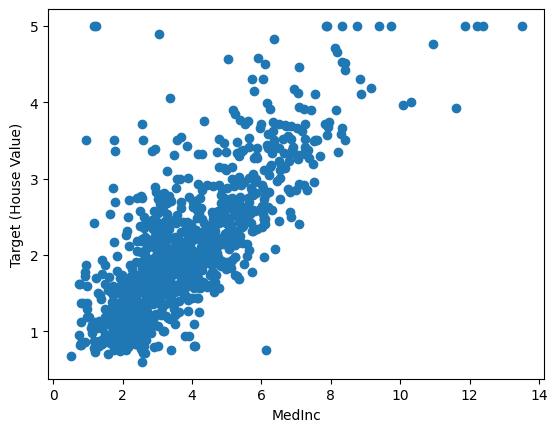

In [ ]:
# Ваш код здесь
import matplotlib.pyplot as plt

plt.scatter(Xset, yset)
plt.xlabel('MedInc')
plt.ylabel('Target (House Value)')
plt.show()

### 4. KNN из sklearn

#### 4.1. Разбейте данные на обучение и тест

In [ ]:
# Ваш код здесь
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Xset, yset, random_state=10, test_size=100)
X_train.shape, X_test.shape

((900, 1), (100, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [ ]:
# Ваш код здесь
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=100)
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели


In [ ]:
# Ваш код здесь
from sklearn.metrics import r2_score

pred_test = model.predict(X_test)
display(r2_score(y_test, pred_test))

0.7373856697004726

#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь
import numpy as np

obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df['Test object 0 dst'] = distance
distances_df

,Label,Test object 0 dst
0,3.235,2.5501
1,1.981,1.3447
2,1.703,1.0554
3,2.359,1.6152
4,1.964,0.1450
...,...,...
895,0.818,3.4338
896,2.102,1.0579
897,4.188,4.9181
898,3.373,1.2220


#### 4.5. Выберите топ  k  соседей


In [ ]:
# Ваш код здесь
k=10
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
317,1.923,0.0036
325,2.060,0.0069
689,2.750,0.0090
526,2.212,0.0118
773,1.926,0.0150
441,2.613,0.0264
515,1.250,0.0267
890,2.103,0.0320
185,1.793,0.0376
342,2.469,0.0377


#### 4.6. Выведите финальное предсказание для этого объекта

In [ ]:
# Ваш код здесь
obj0 = distances_df.sort_values('Test object 0 dst').head(k)
print(f"Предсказание для первого объекта: {obj0['Label'].median()}")

Предсказание для первого объекта: 2.0815


#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
# Ваш код здесь

print(f"Настоящее целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Настоящее целевое значение для объекта: 1.563
Предсказанное целевое значение для объекта: 2.05415


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

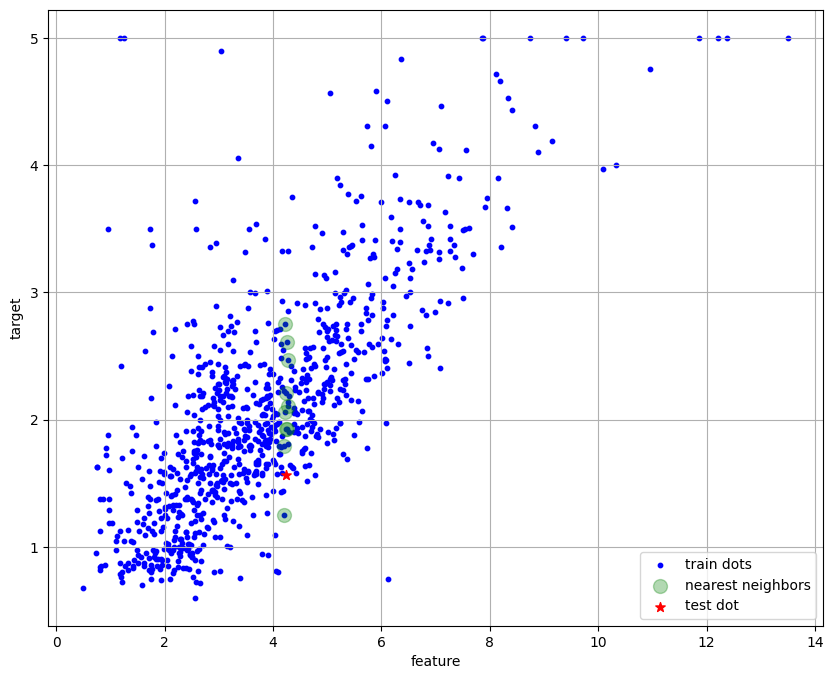

In [ ]:
# Ваш код здесь
import matplotlib.pyplot as plt

nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index
plt.figure(figsize=(10, 8))

plt.scatter(X_train, y_train, c='b', marker='o', s=10, label='train dots')
plt.scatter(X_train.iloc[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=100, label='nearest neighbors')
plt.scatter(X_test.iloc[obj0_idx], y_test[obj0_idx], c='r', marker='*', s=50, label='test dot')
plt.grid()
plt.ylabel('target')
plt.xlabel('feature')
plt.legend()

### 5. Weighted KNN

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [ ]:
# Ваш код здесь
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=100, weights='distance')
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 5.2. Проверьте качество работы модели

In [ ]:
# Ваш код здесь
from sklearn.metrics import r2_score

pred_test = model.predict(X_test)
display(r2_score(y_test, pred_test))

0.6878337357233759

#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [ ]:
# Ваш код здесь
import numpy as np

obj0_idx = 0
x1 = X_test.iloc[obj0_idx]
distances_df = pd.DataFrame()
distances_df['Label'] = y_train
sample = x1.values
distance = np.linalg.norm(X_train.values - sample, axis=1, ord=2)
distances_df[f'Test object 0 dst'] = distance
distances_df

,Label,Test object 0 dst
0,3.235,2.5501
1,1.981,1.3447
2,1.703,1.0554
3,2.359,1.6152
4,1.964,0.1450
...,...,...
895,0.818,3.4338
896,2.102,1.0579
897,4.188,4.9181
898,3.373,1.2220


#### 5.4. Выберите топ  k  соседей

In [ ]:
# Ваш код здесь
k=100
display(distances_df.sort_values('Test object 0 dst').head(k))

,Label,Test object 0 dst
317,1.923,0.0036
325,2.060,0.0069
689,2.750,0.0090
526,2.212,0.0118
773,1.926,0.0150
...,...,...
510,0.938,0.3287
423,1.784,0.3287
375,2.250,0.3287
417,1.842,0.3287


#### 5.5. Рассчитайте вес для каждого соседа

In [ ]:
# Ваш код здесь
distances_df['weight'] = 1 / distances_df['Test object 0 dst']
distances_df

,Label,Test object 0 dst,weight
0,3.235,2.5501,0.392141
1,1.981,1.3447,0.743660
2,1.703,1.0554,0.947508
3,2.359,1.6152,0.619118
4,1.964,0.1450,6.896552
...,...,...,...
895,0.818,3.4338,0.291223
896,2.102,1.0579,0.945269
897,4.188,4.9181,0.203331
898,3.373,1.2220,0.818331


#### 5.6. Выведите финальное предсказание для этого объекта

In [ ]:
# Ваш код здесь
print((distances_df['Label'] * distances_df['weight']).sum() / distances_df['weight'].sum())

2.108126141442349


#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [ ]:
# Ваш код здесь

print(f"Настоящее целевое значение для объекта: {y_test[obj0_idx]}")
print(f"Предсказанное целевое значение для объекта: {model.predict(X_test)[obj0_idx]}")

Настоящее целевое значение для объекта: 1.563
Предсказанное целевое значение для объекта: 2.1149100650455326


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

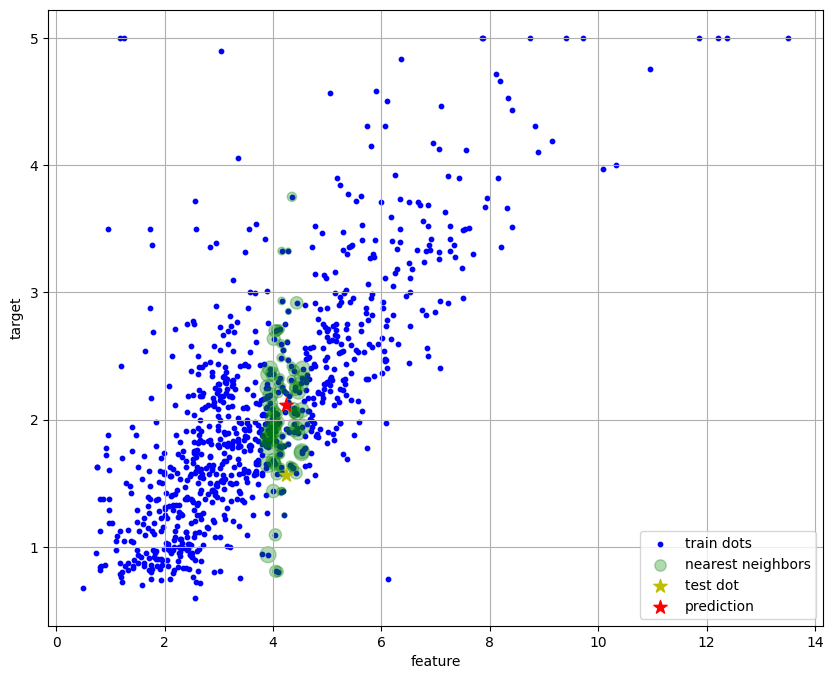

In [ ]:
# Ваш код здесь
plt.figure(figsize=(10, 8))
nearest_neigbors_idxs = distances_df.sort_values('Test object 0 dst').head(k).index

print()
plt.scatter(X_train, y_train, c='b', marker='o', s=10, label='train dots')
plt.grid()

plt.scatter(X_train.iloc[nearest_neigbors_idxs], y_train[nearest_neigbors_idxs],
            c='g', alpha=0.3, marker='o', s=distances_df['Test object 0 dst'].iloc[nearest_neigbors_idxs]*400, label='nearest neighbors')

plt.scatter(X_test['MedInc'].iloc[obj0_idx], y_test[obj0_idx], c='y', marker='*', s=100, label='test dot')
plt.scatter(X_test['MedInc'].iloc[obj0_idx], pred_test[obj0_idx], c='r', marker='*', s=100, label='prediction')

plt.xlabel('feature')
plt.ylabel('target')

plt.legend()

## 6. Еще одна задача регрессии

### Получение данных

Будем работать с тем же самым набором данным `fetch_olivetti_faces` из `sklearn`, но уже для задачи регрессии - будем восстанавливать изображение.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [ ]:
n_pixels = data.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2]
# Lower half of the faces
y_train = train[:, n_pixels // 2:]


X_test = test[:, :(n_pixels + 1) // 2]
y_test = test[:, n_pixels // 2:]

Вот один пример обучающей пары.

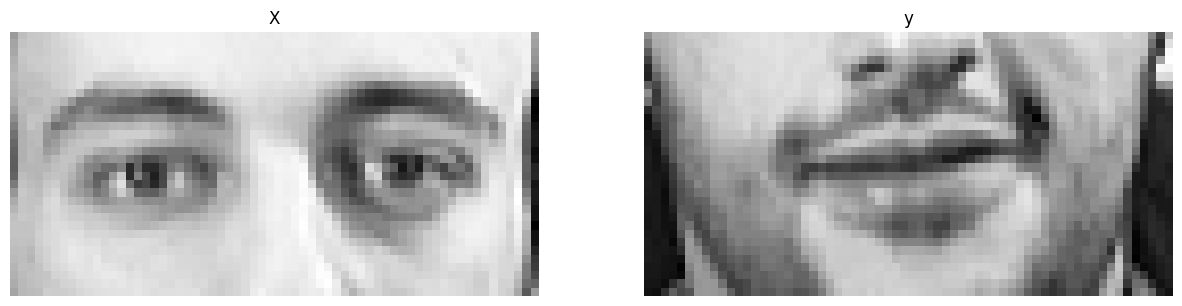

In [ ]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx].reshape((32, 64)), cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx].reshape((32, 64)), cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

#### 6.1. Обучите модель KNN и назовите переменную с моделью knn на 100 соседях

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=100)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 6.2. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом knn.


In [ ]:
pred_test = {'knn': None,
             'weighted_knn': None,
             'weighted_knn_custom': None}

In [ ]:
from sklearn.metrics import r2_score

pred_test = {'knn': knn.predict(X_test),
             'weighted_knn': None,
             'weighted_knn_custom': None}
display(r2_score(y_test, pred_test['knn']))

0.21050623059272766

#### 6.3. Обучите модель KNN с весами по дистанции и назовите переменную с моделью weighted_knn на 100 соседях

In [ ]:
weighted_knn = KNeighborsRegressor(n_neighbors=100, weights='distance')
weighted_knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 6.4. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом weighted_knn.


In [ ]:
pred_test['weighted_knn'] = weighted_knn.predict(X_test)
display(r2_score(y_test, pred_test['weighted_knn']))

0.24241627640538166

#### 6.5. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)


In [ ]:
def count_dist(dists):
  return 1/dists

#### 6.6. Обучите модель KNN с кастомными весами по дистанции и назовите переменную с моделью weighted_knn_custom на 100 соседях

In [ ]:
weighted_knn_custom = KNeighborsRegressor(n_neighbors=100, weights=count_dist)
weighted_knn_custom.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100,
                    weights=<function count_dist at 0x7b123f75db20>)

#### 6.7. Проверьте качество работы модели

При этом предсказания модели запишите в словарь pred_test с ключом weighted_knn_custom.


In [ ]:
pred_test['weighted_knn_custom'] = weighted_knn_custom.predict(X_test)
display(r2_score(y_test, pred_test['weighted_knn_custom']))

0.24241627640538166

А сейчас отрисуем все предсказания.

In [ ]:
ESTIMATORS = {'knn': knn,
              'weighted_knn': weighted_knn,
              'weighted_knn_custom': weighted_knn_custom}

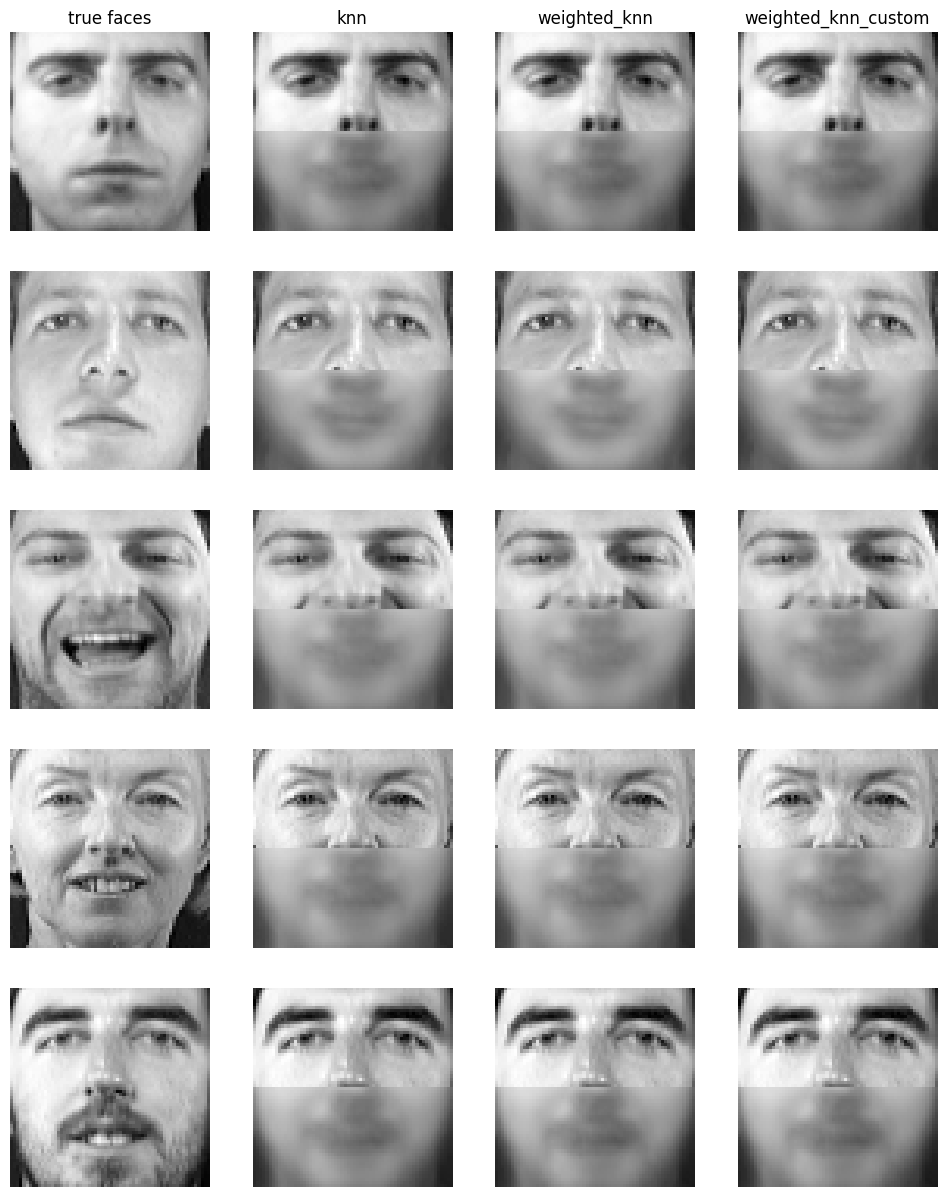

In [ ]:
n_faces = 5
n_cols = 1 + len(ESTIMATORS)
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.hstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    for j, est in enumerate(sorted(ESTIMATORS)):
        completed_face = np.hstack((X_test[i], pred_test[est][i]))

        if i:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j)

        else:
            sub = plt.subplot(n_faces, n_cols, i * n_cols + 2 + j, title=est)

        sub.axis("off")
        sub.imshow(
            completed_face.reshape(image_shape),
            cmap=plt.cm.gray,
            interpolation="nearest",
        )

#### 7*. Подберите лучшие гиперпараметры для модели, используя метод [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [ ]:
from sklearn.model_selection import GridSearchCV

k_range = list(range(1, 201))
param_grid = dict(n_neighbors=k_range)
grid1 = GridSearchCV(knn, param_grid, cv=5)
grid2 = GridSearchCV(weighted_knn, param_grid, cv=5)
grid3 = GridSearchCV(weighted_knn_custom, param_grid, cv=5)

grid1_search=grid1.fit(X_train, y_train)
grid2_search=grid2.fit(X_train, y_train)
grid3_search=grid3.fit(X_train, y_train)

print(f"knn: {grid1_search.best_params_}")
print(f"weighted knn: {grid2_search.best_params_}")

knn: {'n_neighbors': 3}
weighted knn: {'n_neighbors': 4}
weighted knn custom: {'n_neighbors': 4}
